# Bayesian Methods for Credit Risk Modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import statsmodels.api as sm
from scipy import stats
from scipy.stats import lognorm
from sklearn.metrics import roc_auc_score
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from statsmodels.othermod.betareg import BetaModel
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tobit_reg import TobitRegression
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.special import gamma, gammaln
from scipy.stats import beta
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from lifelines import CoxPHFitter
import pymc as pm
import arviz as az
from lifelines import CoxTimeVaryingFitter


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
csvs_path = [rf'datasets/{name}.csv' for name in ['hmeq', 'lgd', 'ratings', 'mortgage']]
hmeq, lgd, ratings, mortgage = list(map(pd.read_csv, csvs_path))

Bayesian statistics is an alternative perspective of statistics compared to the classical frequentist approach. The subjective probabilities make up the prior distribution of events under consideration. In other words, information from the sample data is complemented by prior (subjective) information and assumptions. Bayesian statistics can provide powerful tools, particularly for sparse data such as short time series or credit portfolios with small number of defaults. However, the prior assumptions have to be chosen wisely, as these may dominate the posterior outcome.

| | Frequentist | Bayesian |
| :--- | :--- | :--- |
| **Probability view** | Objective | Subjective |
| **Data** | Data are a repeatable random sample | Data are observed from a realized sample |
| **Parameters** | Parameters are unknown but fixed | Parameters are unknown but random |
| **Estimation criterion** | Unbiasedness, consistency | Minimizing a loss function |
| **Parameter estimate** | Point estimate from estimation approach | Location measure (e.g., mean) of posterior distribution |
| **Interval** | Confidence interval | Credibility interval from posterior distribution |
| **Hypothesis testing** | Via $p$-value | Via marginal likelihoods of various models |

For example, we could have a situation like this:

- Frequentist: "Based on the 500 loans we gave out last month, the default rate is 2%."

- Bayesian: "Historically, this type of loan defaults at 1% (Prior). Last month, we saw 2% (Data). Combining these, our updated risk estimate for next month is 1.2% (Posterior)."

Which illustrates the difference between the two views.

### The Bayesian Approach to Statistics

To understand the Bayesian approach more formally, we start with Bayes' Theorem. Consider two random events A and B. Bayes' theorem states that the conditional probability of A given B is:

$$P(A|B) = \frac{P(B|A)P(A)}{P(B)}$$

Now, if we consider random data Y and parameter $\theta$, Bayes' theorem gives the posterior distribution

$$f(\theta|y) = \frac{f(y|\theta)f(\theta)}{f(y)}$$

where $f(\theta|y) = \frac{f(y|\theta)f(\theta)}{f(y)}d\theta$ is the unconditional distribution of the data and $f(y|\theta)$ is the likelihood function. This basically indicates that the conditional (posterior) distribution of the parameter $\theta$ given some realized data $y$ is the ratio of the product of the likelihood and the prior distribution $f(\theta)$ of the parameter divided by the unconditional distribution of the data. The prior distribution may consist of further parameters, which are called hyperparameters and can also be modeled as random variables with hyperprior distributions, and so forth.

The likelihood function is given by a model and the data as in the frequentist approach. The prior distribution is prespecified by the Bayesian statistician according to her or his beliefs and prior experiences or from other data sources. Unless we assume special cases for the likelihood and the prior, the posterior distribution cannot be evaluated analytically. Rather, the evaluation can be performed via a special Monte Carlo technique, the Markov chain-Monte Carlo (MCMC) method, which generates a large number of simulation trials via special sampling algorithms in order to approximate the posterior.

Once the posterior distribution is generated, analogously to the frequentist approach, estimates of the moments of the posterior and so called credibility intervals can be derived. However, instead of claiming specific properties for the estimators, such as unbiasedness and consistency, the Bayesian criterion for creating an estimator is the minimization of a "loss function". Consider a loss function $L(\hat{\theta}, \theta)$, which specifies the loss incurred by using estimate $\hat{\theta}$ instead of the true $\theta$. Examples are

- Absolute value loss function:
$$L_1(\hat{\theta}, \theta) = |\hat{\theta}-\theta|$$

- Quadratic loss function:
$$L_2(\hat{\theta}, \theta) = (\hat{\theta}-\theta)^2$$

- Bilinear loss function:

$$L_3(\hat{\theta}, \theta) = \begin{cases} a |\hat{\theta} - \theta| & \text{for } \theta > \hat{\theta} \\ b |\hat{\theta} - \theta| & \text{for } \theta \le \hat{\theta} \end{cases}$$

where $a, b > 0$

The Bayes estimator for $\theta$ is the value $\hat{\theta}$ that minimizes the expected value of the loss, where expectation is taken over the posterior distribution; that is, $\hat{\theta}$ is chosen to minimize

$$E[L(\hat{\theta}, \theta)] = \int L(\hat{\theta}, \theta)f(\theta | y) d\theta$$

For example, under quadratic loss we minimize

$$E[L(\hat{\theta}, \theta)] = \int (\hat{\theta} - \theta)^2 f(\theta | y) d\theta$$


We then differentiate with respect to $\hat{\theta}$ and set the result equal to zero:

$$2 \int (\hat{\theta} - \theta)f(\theta | y) d\theta = 0$$

$$\hat{\theta} = \int \theta f(\theta | y) d\theta$$

Hence, under the quadratic loss function the Bayes estimator is $\hat{\theta} = E(\theta | y)$ (i.e., the expectation of the posterior distribution). For computing credibility intervals, the Bayesian approach reports an interval estimate of the form

$$P(\theta_L \le \theta \le \theta_U) = 0.95$$

In other words, it requires that the probability of the parameter $\theta$ being between a lower bound $\theta_L$ and an upper bound $\theta_U$ equals some (high) probability (e.g., 95% or 99%).

Given the posterior distribution, forecasts for out-of-sample (e.g., future) observations can be derived. Let $y_f$ be some forecast, then its density, given the observed data $y$ and the posterior distribution is given by

$$f(y_f | y) = \int f(y_f | \theta, y)f(\theta | y) d\theta$$

This implies that one computes the probability or density of $y$ given the data and given some parameter value, and mixes over the (posterior) density of all potential parameter values.

Some of these may sound familiar to those that are familiar with machine learning, as when you are using regularization, for example, to prevent overfitting, you are adding a penalty to the loss function; in Bayesian terms, you are actually applying a Prior distribution that says, "I believe the weights should be close to zero unless the data strongly proves otherwise".

## PD Estimation With Bayesian Statistics

### Probit Analysis

As bayesian approach generally requires evaluating the posterior distribution by MCMC, it might have a longer running time. As to try reducing this time, we will use a simple like the book.

In [3]:
mortgage['time1'] = mortgage['time'] - mortgage['first_time']
mortgage['time2'] = mortgage['time'] - mortgage['first_time'] + 1
sample = mortgage.sample(frac=0.01, random_state=12345).copy()

# Frequentist
X = sample[['FICO_orig_time', 'LTV_orig_time', 'gdp_time']]
X = sm.add_constant(X) # SAS includes an intercept by default
y = sample['default_time']
probit_model = sm.Probit(y, X)
probit_results = probit_model.fit()
print(probit_results.summary())

Optimization terminated successfully.
         Current function value: 0.108020
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:           default_time   No. Observations:                 6225
Model:                         Probit   Df Residuals:                     6221
Method:                           MLE   Df Model:                            3
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                 0.04394
Time:                        23:06:18   Log-Likelihood:                -672.42
converged:                       True   LL-Null:                       -703.33
Covariance Type:            nonrobust   LLR p-value:                 2.418e-13
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.0608      0.462     -2.297      0.022      -1.966      -0.156
FICO_orig_time   

Due to how long it was taking on my machine, I chose to reduce some parameters, such as the number of draws. I also re-sampled our data

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta0, beta1, beta2, beta3]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 2081 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta0 -2.089  0.098  -2.265   -1.901      0.002    0.002    1835.0    1457.0   
beta1 -0.127  0.093  -0.289    0.063      0.002    0.002    1881.0    1646.0   
beta2  0.176  0.094   0.004    0.353      0.002    0.002    2145.0    1605.0   
beta3 -0.042  0.087  -0.198    0.133      0.002    0.002    1887.0    1391.0   

       r_hat  
beta0    1.0  
beta1    1.0  
beta2    1.0  
beta3    1.0  


array([[<Axes: title={'center': 'beta0'}>,
        <Axes: title={'center': 'beta0'}>],
       [<Axes: title={'center': 'beta1'}>,
        <Axes: title={'center': 'beta1'}>],
       [<Axes: title={'center': 'beta2'}>,
        <Axes: title={'center': 'beta2'}>],
       [<Axes: title={'center': 'beta3'}>,
        <Axes: title={'center': 'beta3'}>]], dtype=object)

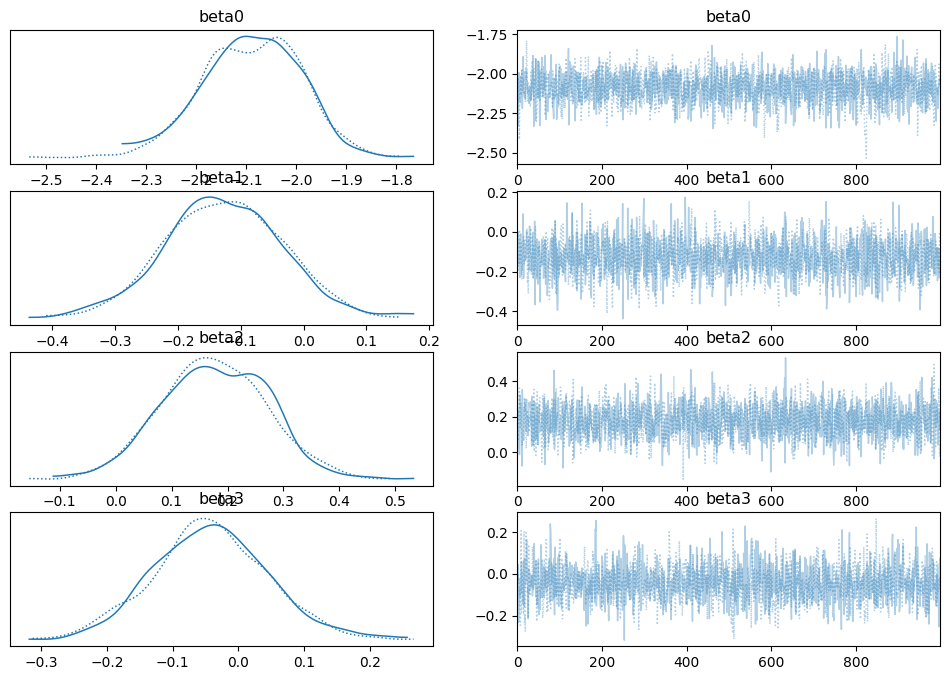

In [4]:
fico_vals = sample['FICO_orig_time'].values
ltv_vals = sample['LTV_orig_time'].values
gdp_vals = sample['gdp_time'].values
y_obs = sample['default_time'].values

np.random.seed(42)
idx = np.random.choice(len(y_obs), size=1000, replace=False)

fico_s = fico_vals[idx]
ltv_s  = ltv_vals[idx]
gdp_s  = gdp_vals[idx]
y_s    = y_obs[idx]

fico_std = (fico_s - fico_s.mean()) / fico_s.std()
ltv_std  = (ltv_s  - ltv_s.mean())  / ltv_s.std()
gdp_std  = (gdp_s  - gdp_s.mean())  / gdp_s.std()

with pm.Model() as bayesian_probit:
    beta0 = pm.Normal("beta0", mu=0, sigma=5)
    beta1 = pm.Normal("beta1", mu=0, sigma=5)
    beta2 = pm.Normal("beta2", mu=0, sigma=5)
    beta3 = pm.Normal("beta3", mu=0, sigma=5)

    mu = beta0 + beta1 * fico_std + beta2 * ltv_std + beta3 * gdp_std
    pd_est = pm.math.invprobit(mu)
    pm.Bernoulli("default_time", p=pd_est, observed=y_s)

    trace = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        cores=2,
        target_accept=0.9,
        initvals={"beta0": 0, "beta1": 0, "beta2": 0, "beta3": 0},
        random_seed=42,
        progressbar=True,
    )

print(az.summary(trace))
az.plot_trace(trace)

In [5]:
vars = ['beta0', 'beta1', 'beta2', 'beta3']
# Generate the summary table
summary = az.summary(trace, var_names=vars, hdi_prob=0.95, kind='stats')
post = trace.posterior.to_dataframe()
for p in [25, 50, 75]:
    summary[f'{p}%'] = [post[v].quantile(p/100) for v in vars]

print("--- Posterior Summaries and Intervals ---")
print(summary[['mean', 'sd', '25%', '50%', '75%', 'hdi_2.5%', 'hdi_97.5%']])

--- Posterior Summaries and Intervals ---
        mean     sd       25%       50%       75%  hdi_2.5%  hdi_97.5%
beta0 -2.089  0.098 -2.155582 -2.086039 -2.018438    -2.300     -1.920
beta1 -0.127  0.093 -0.189196 -0.129160 -0.064725    -0.310      0.059
beta2  0.176  0.094  0.112691  0.176249  0.242326     0.004      0.367
beta3 -0.042  0.087 -0.098778 -0.043592  0.015384    -0.205      0.141



--- Posterior Correlation Matrix ---
        beta0   beta1   beta2   beta3
beta0  1.0000  0.2097 -0.2464  0.1334
beta1  0.2097  1.0000  0.1819  0.0881
beta2 -0.2464  0.1819  1.0000 -0.0126
beta3  0.1334  0.0881 -0.0126  1.0000


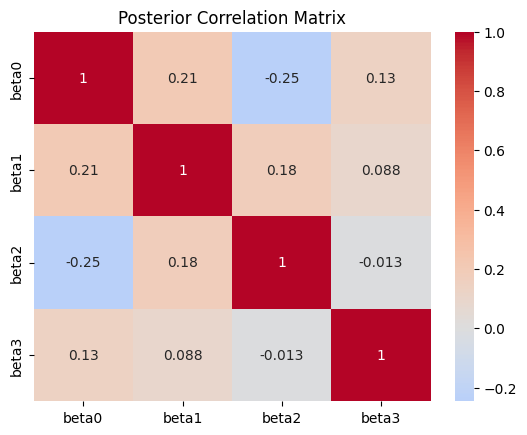

In [6]:
var_names = ['beta0', 'beta1', 'beta2', 'beta3']
samples = (
    trace.posterior[var_names]
    .to_dataframe()
    .reset_index(drop=True)
)
corr_matrix = samples.corr()
print("\n--- Posterior Correlation Matrix ---")
print(corr_matrix.round(4))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Posterior Correlation Matrix")
plt.show()

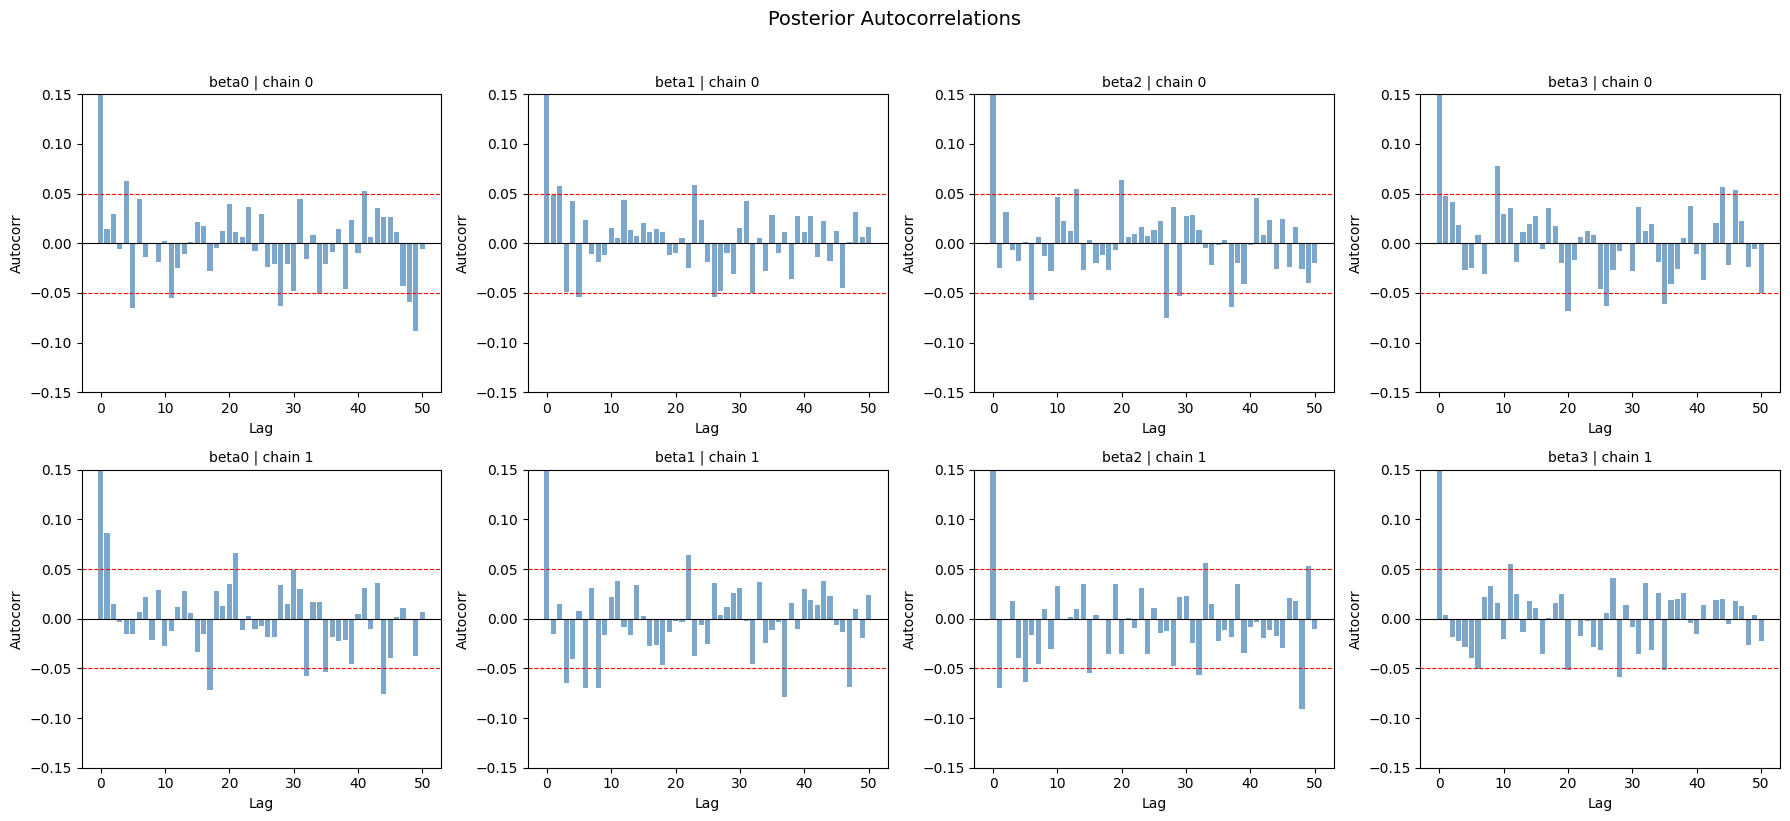

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))  # bigger figure

for i, v in enumerate(var_names):
    for chain in range(2):
        ax = axes[chain, i] if i < 4 else axes[chain, i-4]
        chain_samples = trace.posterior[v].values[chain]
        lags = range(51)
        acf_vals = [pd.Series(chain_samples).autocorr(lag=l) if l > 0 else 1.0 for l in lags]
        
        ax.bar(lags, acf_vals, color='steelblue', alpha=0.7, width=0.8)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='±0.05')
        ax.axhline(-0.05, color='red', linestyle='--', linewidth=0.8)
        ax.set_ylim(-0.15, 0.15)  # zoom in so small values are visible
        ax.set_title(f"{v} | chain {chain}", fontsize=10)
        ax.set_xlabel("Lag")
        ax.set_ylabel("Autocorr")

plt.suptitle("Posterior Autocorrelations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [8]:
X_s = pd.DataFrame({
    'FICO_orig_time': fico_s,
    'LTV_orig_time':  ltv_s,
    'gdp_time':       gdp_s
})
X_s = sm.add_constant(X_s)
y_s = pd.Series(y_s)

probit_model_s = sm.Probit(y_s, X_s)
probit_results_s = probit_model_s.fit()
print(probit_results_s.summary())

Optimization terminated successfully.
         Current function value: 0.102571
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1000
Model:                         Probit   Df Residuals:                      996
Method:                           MLE   Df Model:                            3
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                 0.02982
Time:                        23:41:03   Log-Likelihood:                -102.57
converged:                       True   LL-Null:                       -105.72
Covariance Type:            nonrobust   LLR p-value:                   0.09768
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.1610      1.204     -1.794      0.073      -4.521       0.199
FICO_orig_time   

In [9]:
freq_df = pd.DataFrame({
    'Variable':      probit_results_s.params.index,
    'Freq_Coef':     probit_results_s.params.values,
    'Freq_SE':       probit_results_s.bse.values,
    'Freq_Lower_95': probit_results_s.conf_int()[0].values,
    'Freq_Upper_95': probit_results_s.conf_int()[1].values
})

bay_summary = az.summary(trace, var_names=['beta0', 'beta1', 'beta2', 'beta3'], hdi_prob=0.95)
hdi_low  = [c for c in bay_summary.columns if 'hdi' in c and ('2' in c or '3' in c)][0]
hdi_high = [c for c in bay_summary.columns if 'hdi' in c and '97' in c][0]

b0 = bay_summary.loc['beta0', 'mean']
b1 = bay_summary.loc['beta1', 'mean']
b2 = bay_summary.loc['beta2', 'mean']
b3 = bay_summary.loc['beta3', 'mean']

b0_orig = b0 - (b1 * fico_s.mean() / fico_s.std()) \
             - (b2 * ltv_s.mean()  / ltv_s.std())  \
             - (b3 * gdp_s.mean()  / gdp_s.std())
b1_orig = b1 / fico_s.std()
b2_orig = b2 / ltv_s.std()
b3_orig = b3 / gdp_s.std()

bay_df = pd.DataFrame({
    'Variable':       ['const', 'FICO_orig_time', 'LTV_orig_time', 'gdp_time'],
    'Bayes_Mean':     [b0_orig, b1_orig, b2_orig, b3_orig],
    'Bayes_hdi_low':  bay_summary[hdi_low].values,
    'Bayes_hdi_high': bay_summary[hdi_high].values,
})

comparison = pd.merge(freq_df, bay_df, on='Variable')
print(comparison.round(4))

         Variable  Freq_Coef  Freq_SE  Freq_Lower_95  Freq_Upper_95  \
0           const    -2.1610   1.2043        -4.5215         0.1994   
1  FICO_orig_time    -0.0018   0.0013        -0.0042         0.0007   
2   LTV_orig_time     0.0166   0.0094        -0.0018         0.0351   
3        gdp_time    -0.0225   0.0424        -0.1057         0.0607   

   Bayes_Mean  Bayes_hdi_low  Bayes_hdi_high  
0     -2.2341         -2.300          -1.920  
1     -0.0017         -0.310           0.059  
2      0.0171          0.004           0.367  
3     -0.0207         -0.205           0.141  


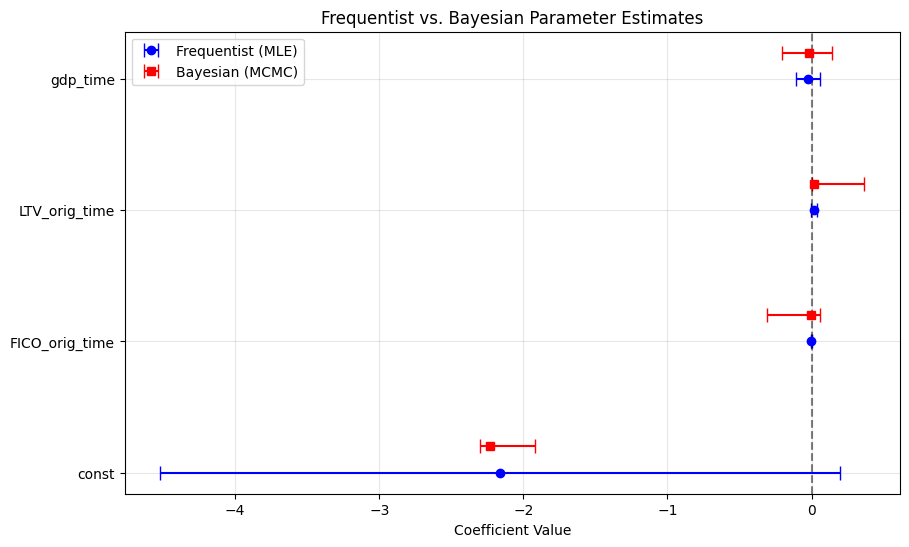

In [10]:
plt.figure(figsize=(10, 6))
plt.errorbar(comparison['Freq_Coef'], range(len(comparison)), 
             xerr=[comparison['Freq_Coef'] - comparison['Freq_Lower_95'], 
                   comparison['Freq_Upper_95'] - comparison['Freq_Coef']],
             fmt='o', color='blue', label='Frequentist (MLE)', capsize=5)
plt.errorbar(comparison['Bayes_Mean'], [x + 0.2 for x in range(len(comparison))], 
             xerr=[comparison['Bayes_Mean'] - comparison['Bayes_hdi_low'], 
                   comparison['Bayes_hdi_high'] - comparison['Bayes_Mean']],
             fmt='s', color='red', label='Bayesian (MCMC)', capsize=5)
plt.yticks(range(len(comparison)), comparison['Variable'])
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Frequentist vs. Bayesian Parameter Estimates')
plt.xlabel('Coefficient Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Instead of letting all the variables float freely with wide, uninformative priors (variance = 1000), the researcher has hard-coded a strong belief about $\beta_2$​ (LTV_orig_time). They are telling the model: "Before looking at any data, I firmly believe the coefficient for LTV is centered around 3, with a very tight variance of 0.5."

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta0, beta1, beta3, beta2]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 2124 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


        mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta0 -2.106  0.101    -2.305     -1.903      0.002    0.002    1977.0   
beta1 -0.120  0.094    -0.299      0.064      0.002    0.002    1589.0   
beta2  0.231  0.104     0.029      0.428      0.002    0.002    1882.0   
beta3 -0.033  0.086    -0.206      0.135      0.002    0.002    1618.0   

       ess_tail  r_hat  
beta0    1568.0    1.0  
beta1    1198.0    1.0  
beta2    1353.0    1.0  
beta3    1110.0    1.0  

--- Rescaled Bayesian Coefficients (original scale) ---
const: mean=-2.7412, HDI=[-5.3741, -0.2973]
FICO_orig_time: mean=-0.0017, HDI=[-0.0041, 0.0009]
LTV_orig_time: mean=0.0225, HDI=[0.0028, 0.0417]
gdp_time: mean=-0.0164, HDI=[-0.1016, 0.0666]
         Variable  Freq_Coef  Freq_SE  Freq_Lower_95  Freq_Upper_95  \
0           const    -2.1610   1.2043        -4.5215         0.1994   
1  FICO_orig_time    -0.0018   0.0013        -0.0042         0.0007   
2   LTV_orig_time     0.0166   0.0094      

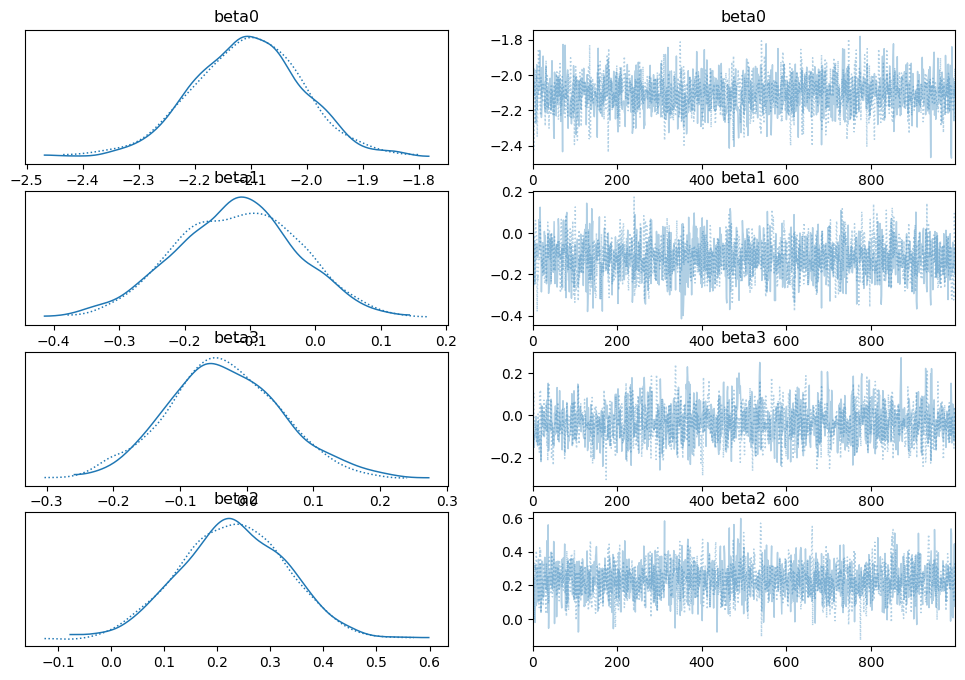

In [11]:
np.random.seed(42)
idx = np.random.choice(len(y_obs), size=1000, replace=False)

fico_s = fico_vals[idx]
ltv_s  = ltv_vals[idx]
gdp_s  = gdp_vals[idx]
y_s    = y_obs[idx]

fico_std = (fico_s - fico_s.mean()) / fico_s.std()
ltv_std  = (ltv_s  - ltv_s.mean())  / ltv_s.std()
gdp_std  = (gdp_s  - gdp_s.mean())  / gdp_s.std()

with pm.Model() as bayesian_probit_informative:
    beta0 = pm.Normal("beta0", mu=0, sigma=5)
    beta1 = pm.Normal("beta1", mu=0, sigma=5)
    beta3 = pm.Normal("beta3", mu=0, sigma=5)
    beta2 = pm.Normal("beta2", mu=3, sigma=np.sqrt(0.5))

    mu = beta0 + beta1 * fico_std + beta2 * ltv_std + beta3 * gdp_std
    pd_est = pm.math.invprobit(mu)
    pm.Bernoulli("default_time", p=pd_est, observed=y_s)

    trace_informative = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        cores=2,
        target_accept=0.9,
        initvals={"beta0": 0, "beta1": 0, "beta2": 3, "beta3": 0},
        random_seed=12345,
        progressbar=True,
    )

# --- Summary ---
bay_summary_inf = az.summary(trace_informative, var_names=['beta0', 'beta1', 'beta2', 'beta3'], hdi_prob=0.95)
print(bay_summary_inf)
az.plot_trace(trace_informative)

# --- Rescale all posterior draws to original scale ---
b0_draws = trace_informative.posterior['beta0'].values.flatten() \
           - (trace_informative.posterior['beta1'].values.flatten() * fico_s.mean() / fico_s.std()) \
           - (trace_informative.posterior['beta2'].values.flatten() * ltv_s.mean()  / ltv_s.std())  \
           - (trace_informative.posterior['beta3'].values.flatten() * gdp_s.mean()  / gdp_s.std())
b1_draws = trace_informative.posterior['beta1'].values.flatten() / fico_s.std()
b2_draws = trace_informative.posterior['beta2'].values.flatten() / ltv_s.std()
b3_draws = trace_informative.posterior['beta3'].values.flatten() / gdp_s.std()

print("\n--- Rescaled Bayesian Coefficients (original scale) ---")
for name, draws in zip(['const', 'FICO_orig_time', 'LTV_orig_time', 'gdp_time'],
                        [b0_draws, b1_draws, b2_draws, b3_draws]):
    hdi = az.hdi(draws, hdi_prob=0.95)
    print(f"{name}: mean={draws.mean():.4f}, HDI=[{hdi[0]:.4f}, {hdi[1]:.4f}]")

# --- Build bay_df_inf for comparison ---
rescaled = {
    'const':          (b0_draws.mean(), az.hdi(b0_draws, hdi_prob=0.95)),
    'FICO_orig_time':  (b1_draws.mean(), az.hdi(b1_draws, hdi_prob=0.95)),
    'LTV_orig_time':   (b2_draws.mean(), az.hdi(b2_draws, hdi_prob=0.95)),
    'gdp_time':        (b3_draws.mean(), az.hdi(b3_draws, hdi_prob=0.95)),
}

bay_df_inf = pd.DataFrame({
    'Variable':       list(rescaled.keys()),
    'Bayes_Mean':     [v[0] for v in rescaled.values()],
    'Bayes_hdi_low':  [v[1][0] for v in rescaled.values()],
    'Bayes_hdi_high': [v[1][1] for v in rescaled.values()],
})

comparison_inf = pd.merge(freq_df, bay_df_inf, on='Variable')
print(comparison_inf.round(4))

### Survival Analysis

Feature columns: ['time', 'orig_time', 'first_time', 'mat_time', 'balance_time', 'LTV_time', 'interest_rate_time', 'hpi_time', 'gdp_time', 'uer_time', 'REtype_CO_orig_time', 'REtype_PU_orig_time', 'REtype_SF_orig_time', 'investor_orig_time', 'balance_orig_time', 'FICO_orig_time', 'LTV_orig_time', 'Interest_Rate_orig_time', 'hpi_orig_time', 'payoff_time', 'status_time']

Std of each column:
time                           11.5615
orig_time                       7.4313
first_time                      6.7834
mat_time                       19.8740
balance_time               215485.4450
LTV_time                       26.0499
interest_rate_time              2.0961
hpi_time                       27.6214
gdp_time                        1.9624
uer_time                        1.9380
REtype_CO_orig_time             0.2492
REtype_PU_orig_time             0.3260
REtype_SF_orig_time             0.4845
investor_orig_time              0.3480
balance_orig_time          222721.0864
FICO_orig_time        

d:\projects\cra_mtae_sas_in_py\.venv\Lib\site-packages\lifelines\utils\__init__.py:1120: ConvergenceWarning: Column payoff_time have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['default_time'].astype(bool)
>>> print(df.loc[events, 'payoff_time'].var())
>>> print(df.loc[~events, 'payoff_time'].var())

A very low variance means that the column payoff_time completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


<lifelines.CoxTimeVaryingFitter: fitted with 6223 periods, 5554 subjects, 149 events>
         event col = 'default_time'
         penalizer = 0.1
number of subjects = 5554
 number of periods = 6223
  number of events = 149
partial log-likelihood = -721.75
  time fit was run = 2026-03-25 03:16:30 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
time                     0.00      1.00      0.00           -0.01            0.01                0.99                1.01
orig_time                0.00      1.00      0.01           -0.01            0.01                0.99                1.01
first_time               0.00      1.00      0.01           -0.01            0.01                0.99                1.01
mat_time                 0.00      1.00      0.00           -0.00            0.01                1.00                1.01
balance_time            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
LTV_time                 0.00      1.00      0.00           -0.00            0.00                1.00                1.00
interest_rate_time       0.03      1.03      0.02           -0.01            0.06                0.99                1.07
hpi_time                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
gdp_time                -0.03      0.97      0.02           -0.06            0.01                0.94                1.01
uer_time                 0.02      1.02      0.02           -0.02            0.06                0.98                1.06
REtype_CO_orig_time      0.02      1.02      0.14           -0.26            0.30                0.77                1.35
REtype_PU_orig_time     -0.07      0.93      0.11           -0.29            0.15                0.75                1.16
REtype_SF_orig_time     -0.02      0.98      0.07           -0.17            0.12                0.84                1.13
investor_orig_time       0.06      1.06      0.10           -0.14            0.27                0.87                1.31
balance_orig_time       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
FICO_orig_time          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
LTV_orig_time            0.00      1.00      0.00           -0.00            0.01                1.00                1.01
Interest_Rate_orig_time -0.01      0.99      0.01           -0.03            0.02                0.97                1.02
hpi_orig_time            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
payoff_time             -0.71      0.49      0.17           -1.05           -0.37                0.35                0.69
status_time              0.99      2.69      0.08            0.83            1.15                2.29                3.16

                         cmp to     z      p  -log2(p)
covariate                                             
time                       0.00  0.25   0.80      0.32
orig_time                  0.00  0.61   0.54      0.89
first_time                 0.00  0.45   0.65      0.62
mat_time                   0.00  0.84   0.40      1.31
balance_time               0.00 -0.22   0.83      0.27
LTV_time                   0.00  1.74   0.08      3.61
interest_rate_time         0.00  1.62   0.10      3.26
hpi_time                   0.00 -0.86   0.39      1.36
gdp_time                   0.00 -1.46   0.14      2.81
uer_time                   0.00  0.87   0.38      1.38
REtype_CO_orig_time        0.00  0.14   0.89      0.16
REtype_PU_orig_time        0.00 -0.61   0.54      0.89
REtype_SF_orig_time        0.00 -0.30   0.77      0.38
investor_orig_time         0.00  0.60   0.55      0.87
balanc

<Axes: xlabel='log(HR) (95% CI)'>

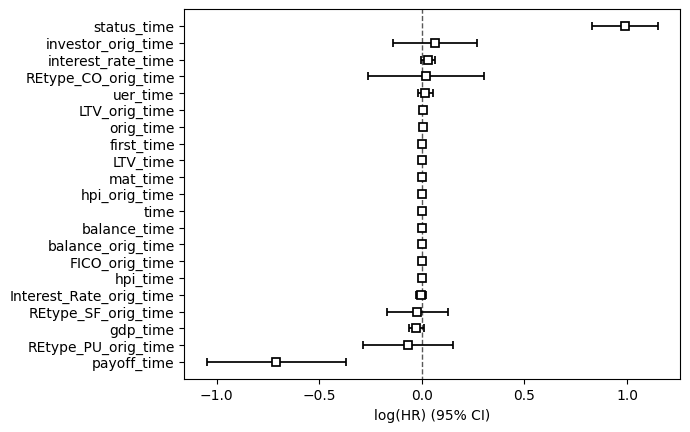

In [12]:
sample_ = sample.dropna()
feature_cols = [c for c in sample_.columns 
                if c not in ['id', 'default_time', 'time1', 'time2']]
print("Feature columns:", feature_cols)
print("\nStd of each column:")
print(sample_[feature_cols].std().round(4))
corr = sample_[feature_cols].corr().abs()
high_corr = [(i, j, corr.loc[i,j]) 
             for i in corr.columns 
             for j in corr.columns 
             if i < j and corr.loc[i,j] > 0.95]
print("\nHighly correlated pairs (>0.95):", high_corr)
non_constant = sample_[feature_cols].std() > 0
good_cols = sample_[feature_cols].columns[non_constant].tolist()
print("\nKeeping columns:", good_cols)
sample_clean = sample_[['id', 'default_time', 'time1', 'time2'] + good_cols].copy()
ctv = CoxTimeVaryingFitter(penalizer=0.1)  # penalizer helps with near-singular matrix
ctv.fit(sample_clean,
        id_col="id",
        event_col="default_time",
        start_col="time1",
        stop_col="time2",
        show_progress=True)
ctv.print_summary()
ctv.plot()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_fico, beta_ltv, beta_gdp, lambda0]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20540 seconds.


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_fico -0.345  0.080  -0.489   -0.192      0.001    0.001    3815.0   
beta_ltv   0.196  0.082   0.041    0.347      0.001    0.001    3842.0   
beta_gdp  -0.386  0.065  -0.506   -0.267      0.001    0.001    4123.0   
lambda0    0.020  0.002   0.017    0.023      0.000    0.000    3835.0   

           ess_tail  r_hat  
beta_fico    2777.0    1.0  
beta_ltv     2485.0    1.0  
beta_gdp     2858.0    1.0  
lambda0      2769.0    1.0  


array([[<Axes: title={'center': 'beta_fico'}>,
        <Axes: title={'center': 'beta_fico'}>],
       [<Axes: title={'center': 'beta_ltv'}>,
        <Axes: title={'center': 'beta_ltv'}>],
       [<Axes: title={'center': 'beta_gdp'}>,
        <Axes: title={'center': 'beta_gdp'}>],
       [<Axes: title={'center': 'lambda0'}>,
        <Axes: title={'center': 'lambda0'}>]], dtype=object)

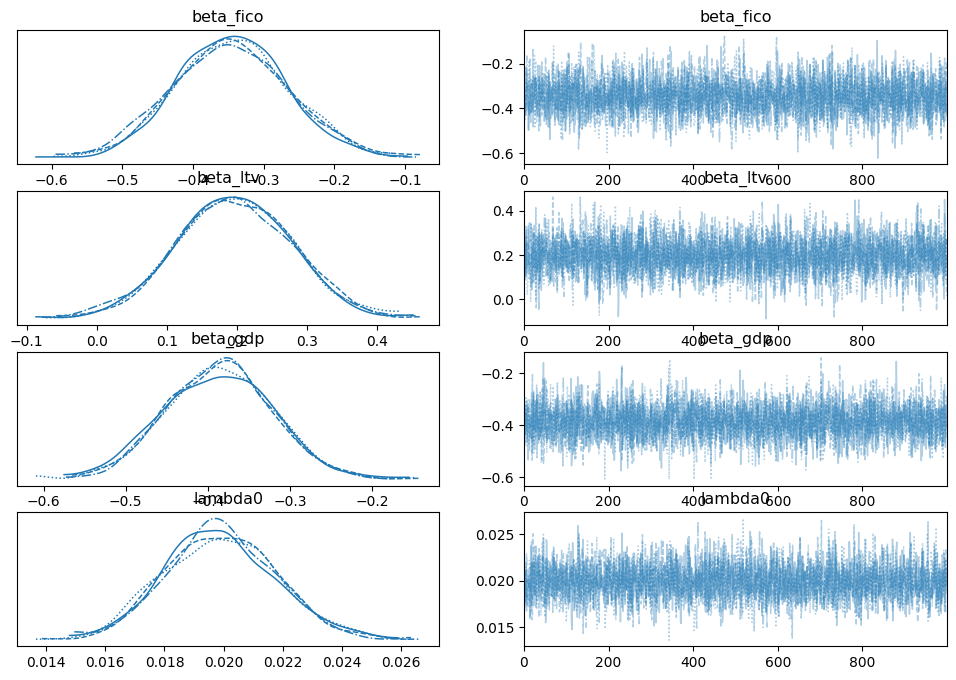

In [13]:
duration = sample['time2'].values - sample['time1'].values
event = sample['default_time'].values
fico = (sample['FICO_orig_time'].values - sample['FICO_orig_time'].mean()) / sample['FICO_orig_time'].std()
ltv  = (sample['LTV_orig_time'].values  - sample['LTV_orig_time'].mean())  / sample['LTV_orig_time'].std()
gdp  = (sample['gdp_time'].values       - sample['gdp_time'].mean())       / sample['gdp_time'].std()

with pm.Model() as bayesian_cox:
    beta_fico = pm.Normal("beta_fico", mu=0, sigma=1)
    beta_ltv = pm.Normal("beta_ltv", mu=0, sigma=1)
    beta_gdp = pm.Normal("beta_gdp", mu=0, sigma=1)
    
    # Using a flat prior for the baseline hazard
    lambda0 = pm.Gamma("lambda0", alpha=0.1, beta=0.1)
    
    log_hazard = (beta_fico * fico + 
                  beta_ltv * ltv + 
                  beta_gdp * gdp)
    
    # For Exponential/Cox models, the log-likelihood is:
    # event * log(hazard) - cumulative_hazard
    hazard = lambda0 * pm.math.exp(log_hazard)
    mu = hazard * duration
    
    # Poisson likelihood trick for survival
    y = pm.Poisson("obs", mu=mu, observed=event)
    
    # We use tune=1000 for the burn-in period
    trace = pm.sample(draws=1000, tune=1000, target_accept=0.95, random_seed=1)

print(az.summary(trace))
az.plot_trace(trace)

### Correlation Estimation with Bayesin Statistics

Assets correlations can also be estimated using the Bayesin approach. We use the same simple aggregated model and the same data as when we estimated correlations. So, we regress $\Phi^{-1}(dr_t)$ on a constant. In other words, we have two parameters, namely a constant coded as $\beta_0$ and the residual standard variance. These can be transformed into the PD and the asset colrrelation as discussed earlier.


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 2 jobs)
NUTS: [beta0, sigma2]


Output()

Sampling 3 chains for 500 tune and 1_000 draw iterations (1_500 + 3_000 draws total) took 639 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta0   0.022  0.005   0.013    0.030        0.0      0.0    3379.0    2004.0   
sigma2  0.022  0.001   0.020    0.024        0.0      0.0    3082.0    2436.0   

        r_hat  
beta0     1.0  
sigma2    1.0  


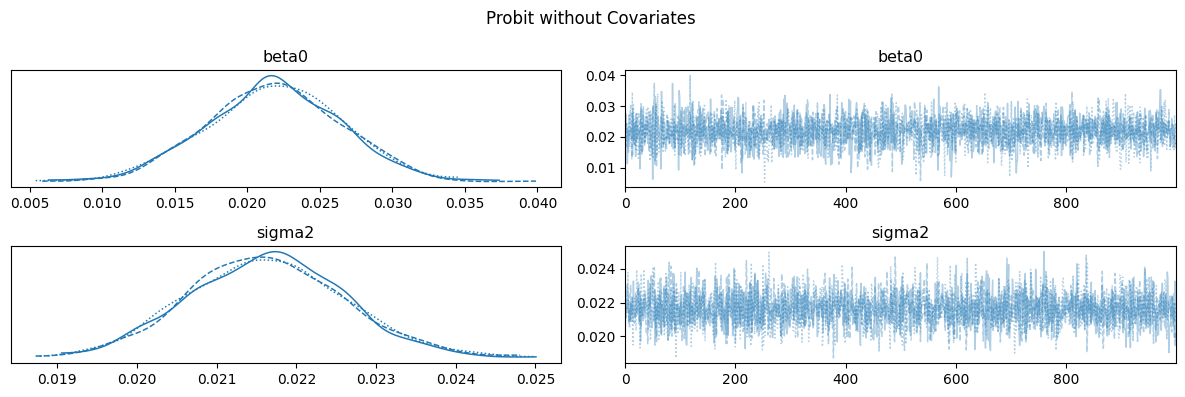

In [14]:
np.random.seed(12345)

with pm.Model() as probit_no_covariates:
    # PRIOR beta0 ~ normal(0, var=10000) -> sigma=sqrt(10000)=100
    beta0 = pm.Normal("beta0", mu=0, sigma=100)
    
    # PRIOR sigma2 ~ Uniform(0, 1)
    sigma2 = pm.Uniform("sigma2", lower=0, upper=1)
    
    # mu = beta0
    mu = beta0
    
    # MODEL probit_dr ~ n(mu, var=sigma2)
    likelihood = pm.Normal("probit_dr", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y_s)
    
    trace_no_cov = pm.sample(
        draws=1000,
        tune=500,
        chains=3,
        cores=2,
        thin=2,          # THIN=2
        random_seed=12345,
        progressbar=True,
    )

print(az.summary(trace_no_cov, var_names=['beta0', 'sigma2']))
az.plot_trace(trace_no_cov)
plt.suptitle("Probit without Covariates")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 2 jobs)
NUTS: [beta0, beta1, beta2, beta3, sigma2]


Output()

Sampling 3 chains for 500 tune and 1_000 draw iterations (1_500 + 3_000 draws total) took 1893 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta0   0.022  0.004   0.013    0.031        0.0      0.0    5012.0    2529.0   
beta1  -0.006  0.005  -0.015    0.002        0.0      0.0    4118.0    2485.0   
beta2   0.008  0.005  -0.000    0.018        0.0      0.0    3560.0    2620.0   
beta3  -0.002  0.004  -0.010    0.006        0.0      0.0    4451.0    2364.0   
sigma2  0.022  0.001   0.020    0.023        0.0      0.0    3932.0    2709.0   

        r_hat  
beta0     1.0  
beta1     1.0  
beta2     1.0  
beta3     1.0  
sigma2    1.0  


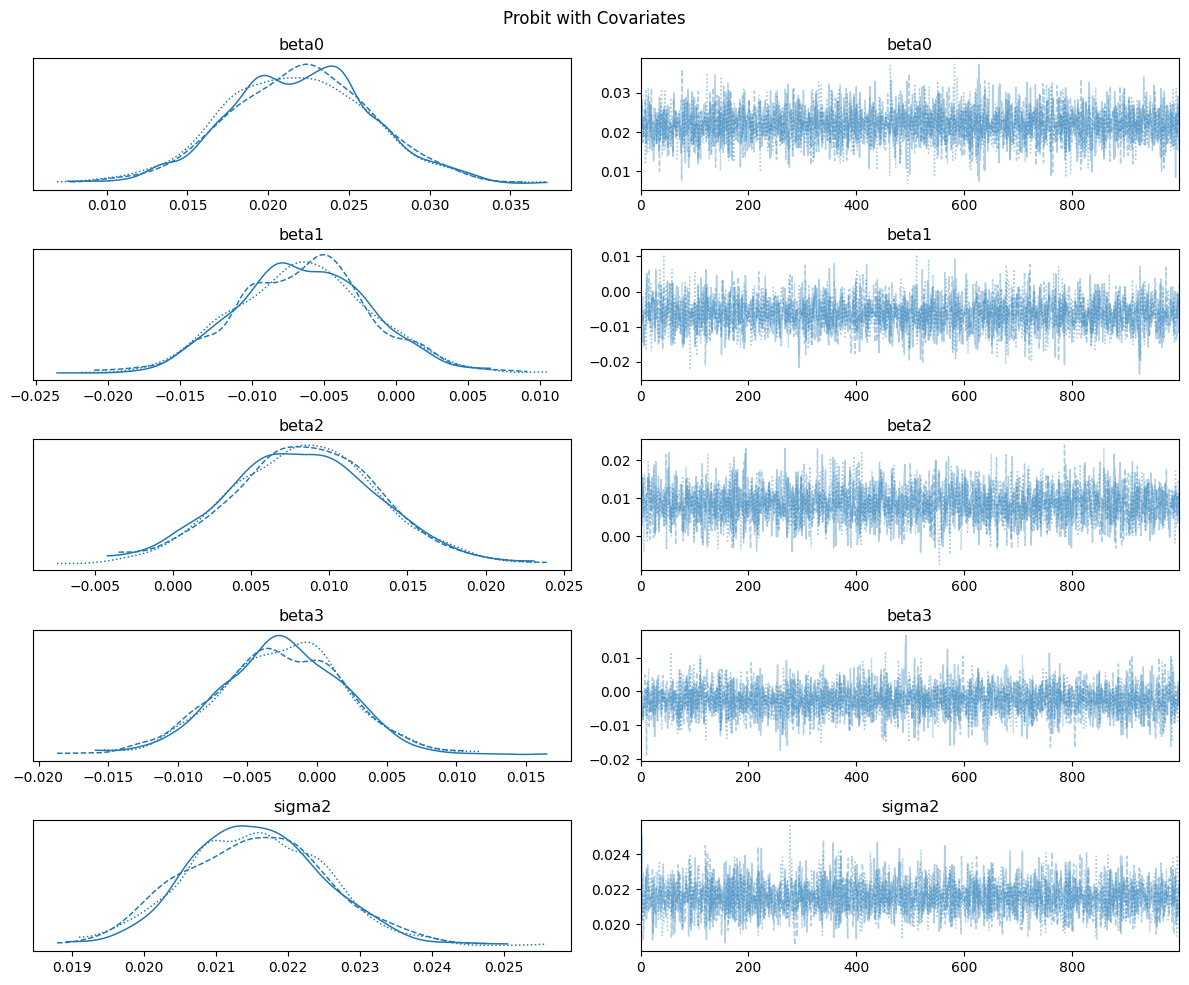

In [15]:
# Probit-Linear Regression with Covariates with MCMC
np.random.seed(12345)

with pm.Model() as probit_with_covariates:
    # PARMS beta0=0, sigma2=0.1 (initial values)
    # PRIOR beta0 ~ normal(0, var=10000)
    beta0 = pm.Normal("beta0", mu=0, sigma=100)
    beta1 = pm.Normal("beta1", mu=0, sigma=100)
    beta2 = pm.Normal("beta2", mu=0, sigma=100)
    beta3 = pm.Normal("beta3", mu=0, sigma=100)

    # PRIOR sigma2 ~ Uniform(0, 1)
    sigma2 = pm.Uniform("sigma2", lower=0, upper=1)


    # mu = beta0 + beta1*fico + beta2*ltv + beta3*gdp
    mu = beta0 + beta1 * fico_std + beta2 * ltv_std + beta3 * gdp_std

    # MODEL probit_dr ~ n(mu, var=sigma2)
    likelihood = pm.Normal("probit_dr", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y_s)

    trace_with_cov = pm.sample(
        draws=1000,
        tune=500,
        chains=3,
        cores=2,
        thin=2,
        random_seed=12345,
        progressbar=True,
    )

print(az.summary(trace_with_cov, var_names=['beta0', 'beta1', 'beta2', 'beta3', 'sigma2']))
az.plot_trace(trace_with_cov)
plt.suptitle("Probit with Covariates")
plt.tight_layout()
plt.show()

### PD Estimation for Low Default Portfolios

An interesting and helpful application of Bayesian statistics is in the case where only sparse data are available, such as low default portfolios (LDPs). The approeaches already presented in this chapter on LDPs can be augmented by Bayesian approaches. Consider a portfolio of 100 loans (n) and 0 defaults (d). Assume further that all loans have the same PD ($\pi$) and are uncorrelated. hence, the number of defaults is binomially distributed. The likelihood function for the parameter $\pi$ is then given by the binomial distribution. The maximum is at value $\pi = 0$ which yields the maximum-likelihood estimator. Similarly, if there were $d \in \{1, 2, 5\}$ defaults, the ML estimate would be at the peak of the likelihood with 1 percent, 2 percent and 5 percent, respectively. Using 0 percent as an estimate for the PD of a segment of a loan portfolio obviously does not make much sense.

We can now mix the sample information with prior information. Suppose there is an expert who specifies a prior of the PD as a beta distribution, for example with parameters $\alpha = 1$ and $\beta = 200$. We can then compute the posterior distribution for various numbers of defaults. However, in Bayesian statistics, we would rather use the mean of the distribution as an estimate for the parameters, which is now about 0.5 percent. Similarly, if $d=5$ the estimate for the PD would no longer be 5 percent but rather somewhere around 2 percent. Hence, the Bayesian estimate for LDP pulls the likelihood toward the prior distribution.

In [16]:
tmp = mortgage[mortgage['FICO_orig_time'] > 810].copy()

print(f"Total observations in 'tmp': {len(tmp)}")
print(f"Total defaults in 'tmp': {tmp['default_time'].sum()}")

Total observations in 'tmp': 1780
Total defaults in 'tmp': 6


In [17]:
# We group by 'time' and calculate mean and count (which is SAS's _FREQ_)
means = tmp.sort_values('time').groupby('time')['default_time'].agg(['mean', 'count']).reset_index()
means.rename(columns={'mean': 'default_time', 'count': '_FREQ_'}, inplace=True)

# Replicating the DATA step logic
means['n_default'] = means['default_time'] * means['_FREQ_']
means['default_time_1'] = means['default_time'].shift(1) # LAG function

# --- Independence Model (Bayesian Beta-Binomial) ---
with pm.Model() as independence_model:
    # PRIOR pd ~ beta(1,1)
    pd = pm.Beta('pd', alpha=1, beta=1)
    
    # MODEL n_default ~ BINOMIAL(_FREQ_, pd)
    y = pm.Binomial('y', n=means['_FREQ_'].values, p=pd, observed=means['n_default'].values)
    
    # MCMC Sampling (SAS NMC=10000)
    trace_indep = pm.sample(draws=1000, tune=500, random_seed=12345)

print(az.summary(trace_indep))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pd]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 28 seconds.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
pd  0.004  0.001   0.002    0.007        0.0      0.0    1605.0    1944.0   

    r_hat  
pd    1.0  


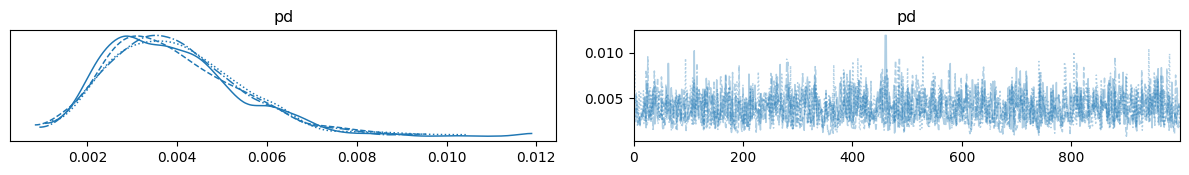

In [18]:
az.plot_trace(trace_indep)
plt.suptitle("")
plt.tight_layout()
plt.show()

In [19]:
X = sm.add_constant(tmp[['LTV_orig_time', 'gdp_time']])
freq_probit = sm.Probit(tmp['default_time'], X).fit()
print(freq_probit.summary())

ltv = (tmp['LTV_orig_time'].values - tmp['LTV_orig_time'].mean()) / tmp['LTV_orig_time'].std()
gdp = (tmp['gdp_time'].values      - tmp['gdp_time'].mean())      / tmp['gdp_time'].std()

with pm.Model() as bayes_ldp_model:
    beta0 = pm.Normal('beta0', mu=0, sigma=2)
    beta1 = pm.Normal('beta1', mu=0, sigma=1)
    beta2 = pm.Normal('beta2', mu=0, sigma=1)

    mu = beta0 + beta1 * ltv + beta2 * gdp
    p  = pm.math.invprobit(mu)
    y  = pm.Bernoulli('y', p=p, observed=tmp['default_time'].values)
    
    # MCMC Sampling
    trace_ldp = pm.sample(draws=1000, tune=500, target_accept=0.95, random_seed=12345)


print(az.summary(trace_ldp))

Optimization terminated successfully.
         Current function value: 0.021439
         Iterations 10


Initializing NUTS using jitter+adapt_diag...


                          Probit Regression Results                           
Dep. Variable:           default_time   No. Observations:                 1780
Model:                         Probit   Df Residuals:                     1777
Method:                           MLE   Df Model:                            2
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                 0.04943
Time:                        06:41:42   Log-Likelihood:                -38.161
converged:                       True   LL-Null:                       -40.146
Covariance Type:            nonrobust   LLR p-value:                    0.1375
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.9734      1.322     -3.762      0.000      -7.564      -2.382
LTV_orig_time     0.0290      0.017      1.737      0.082      -0.004       0.062
gdp_time          0.0367      0.077     

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, beta2]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 4775 seconds.


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta0 -2.883  0.174  -3.210   -2.564      0.004    0.003    2052.0    1941.0   
beta1  0.312  0.166  -0.002    0.612      0.004    0.003    2244.0    2108.0   
beta2  0.107  0.167  -0.174    0.442      0.003    0.003    2893.0    2412.0   

       r_hat  
beta0    1.0  
beta1    1.0  
beta2    1.0  


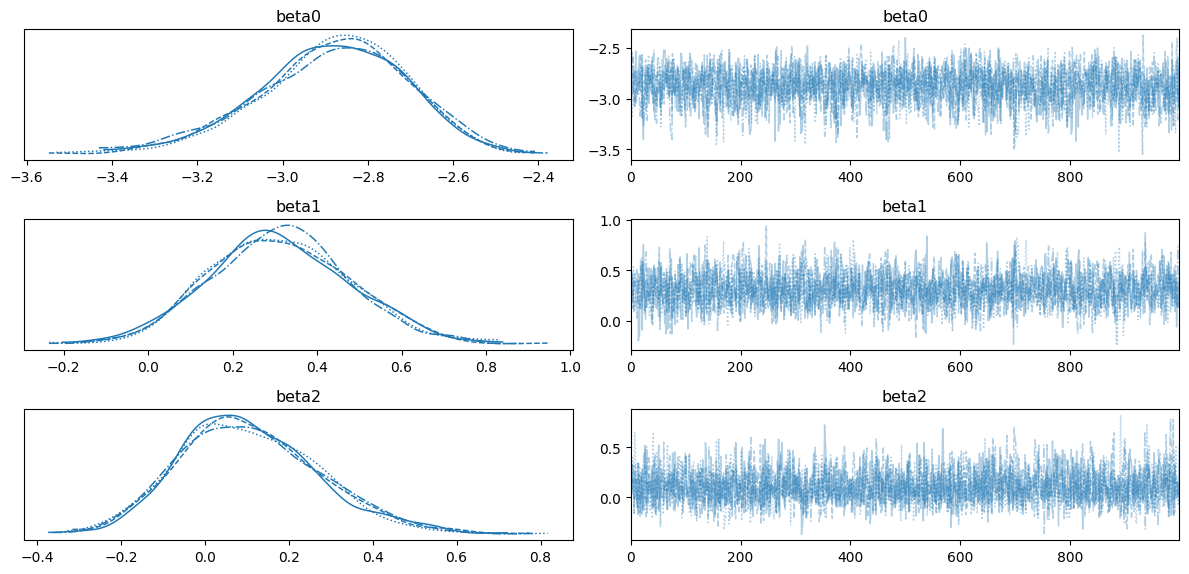

In [20]:
az.plot_trace(trace_ldp)
plt.suptitle("")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pd]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 175 seconds.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
pd  0.004  0.002   0.002    0.008        0.0      0.0    2697.0    3171.0   

    r_hat  
pd    1.0  


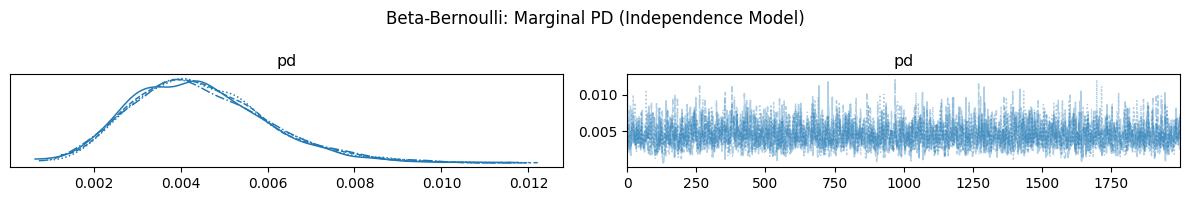

Posterior Mean PD: 0.0045
Frequentist Mean PD: 0.0034


In [21]:
with pm.Model() as ldp_independence:
    pd_param = pm.Beta('pd', alpha=2, beta=2)
    # Bernoulli on raw data — cleaner than binomial on aggregated
    y = pm.Bernoulli('y', p=pd_param, observed=tmp['default_time'].values)

    trace_ldp = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.9,
        random_seed=12345,
        return_inferencedata=True
    )

print(az.summary(trace_ldp))

# Plot
az.plot_trace(trace_ldp)
plt.suptitle("Beta-Bernoulli: Marginal PD (Independence Model)")
plt.tight_layout()
plt.show()

# Extract posterior mean PD
posterior_mean_pd = trace_ldp.posterior['pd'].values.mean()
print(f"Posterior Mean PD: {posterior_mean_pd:.4f}")
print(f"Frequentist Mean PD: {tmp['default_time'].mean():.4f}")  # sanity check